# Import data

In [1]:
import pandas as pd

URL = "data/employee-earnings-report-2021.csv"
df = pd.read_csv(URL,encoding='latin-1')

# Analysis of the dataset

In [2]:
df.shape

(22552, 12)

**The dataset contains 22'552 rows and 12 columns**

In [3]:
missing_per_column = df.isna().sum()
missing_per_column

NAME                             6
DEPARTMENT_NAME                  6
TITLE                            6
REGULAR                        644
RETRO                        22150
OTHER                         8423
OVERTIME                     15706
INJURED                      21096
DETAIL                       20493
QUINN_EDUCATION_INCENTIVE    21166
TOTAL_GROSS                      6
POSTAL                           6
dtype: int64

**The number of missing values is shown from the cell above**

In [4]:
number_of_empty_rows = df.isna().all(axis=1).sum()
number_of_empty_rows

np.int64(6)

**There is a total of 6 empty rows**

# Delete the empty rows

In [5]:
df_clean = df[df.isna().all(axis=1) == False].copy()

In [6]:
df_clean.shape

(22546, 12)

**The dataframe now has 6 fewer rows, which matches our expectations**

## Convert columns type to num

In [7]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 22546 entries, 0 to 22545
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   NAME                       22546 non-null  str  
 1   DEPARTMENT_NAME            22546 non-null  str  
 2   TITLE                      22546 non-null  str  
 3   REGULAR                    21908 non-null  str  
 4   RETRO                      402 non-null    str  
 5   OTHER                      14129 non-null  str  
 6   OVERTIME                   6846 non-null   str  
 7   INJURED                    1456 non-null   str  
 8   DETAIL                     2059 non-null   str  
 9   QUINN_EDUCATION_INCENTIVE  1386 non-null   str  
 10  TOTAL_GROSS                22546 non-null  str  
 11  POSTAL                     22546 non-null  str  
dtypes: str(12)
memory usage: 2.1 MB


We need to make sure the column "regular", "retro", "other", "overtime", "injured", "detail", "quinn_education_incentive", "total_gross", "postal" are converted to numeric type

In [8]:
numeric_cols = ['REGULAR', 'RETRO', 'OTHER', 'OVERTIME', 
                'INJURED', 'DETAIL', 'QUINN_EDUCATION_INCENTIVE', 'TOTAL_GROSS']

for col in numeric_cols:
    df_clean[col] = df_clean[col].str.replace(',', '', regex=False)

df_clean[numeric_cols] = df_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')


# Look for outliers & remove them

Let's find the outliers with by defining 2 bounds. Lower bound is Q1 - 1.5 × IQR , Upper bound is Q3 + 1.5 × IQR. 

If there is data under the lower boud or above the upper bound, we consider them as outliers

In [9]:
Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# See the bounds
bounds = pd.DataFrame({'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 
                       'Lower': lower_bound, 'Upper': upper_bound})
print(bounds)

# Count outliers per column
outlier_mask = (df_clean[numeric_cols] < lower_bound) | (df_clean[numeric_cols] > upper_bound)
print("\nOutlier counts:")
print(outlier_mask.sum())

                                   Q1           Q3         IQR        Lower  \
REGULAR                    36383.8000  107529.7250  71145.9250 -70335.08750   
RETRO                       6614.6125   26694.9950  20080.3825 -23505.96125   
OTHER                        550.0000    3738.0000   3188.0000  -4232.00000   
OVERTIME                    2394.6750   28369.2725  25974.5975 -36567.22125   
INJURED                     4378.3625   51752.4175  47374.0550 -66682.72000   
DETAIL                      2024.0000   23039.7500  21015.7500 -29499.62500   
QUINN_EDUCATION_INCENTIVE  17917.6325   25497.1625   7579.5300   6548.33750   
TOTAL_GROSS                38199.5775  118166.1425  79966.5650 -81750.27000   

                                  Upper  
REGULAR                    214248.61250  
RETRO                       56815.56875  
OTHER                        8520.00000  
OVERTIME                    67331.16875  
INJURED                    122813.50000  
DETAIL                      54563.37

Above we have the number of outliers, let's graph graph every distribution to understand better what is happening

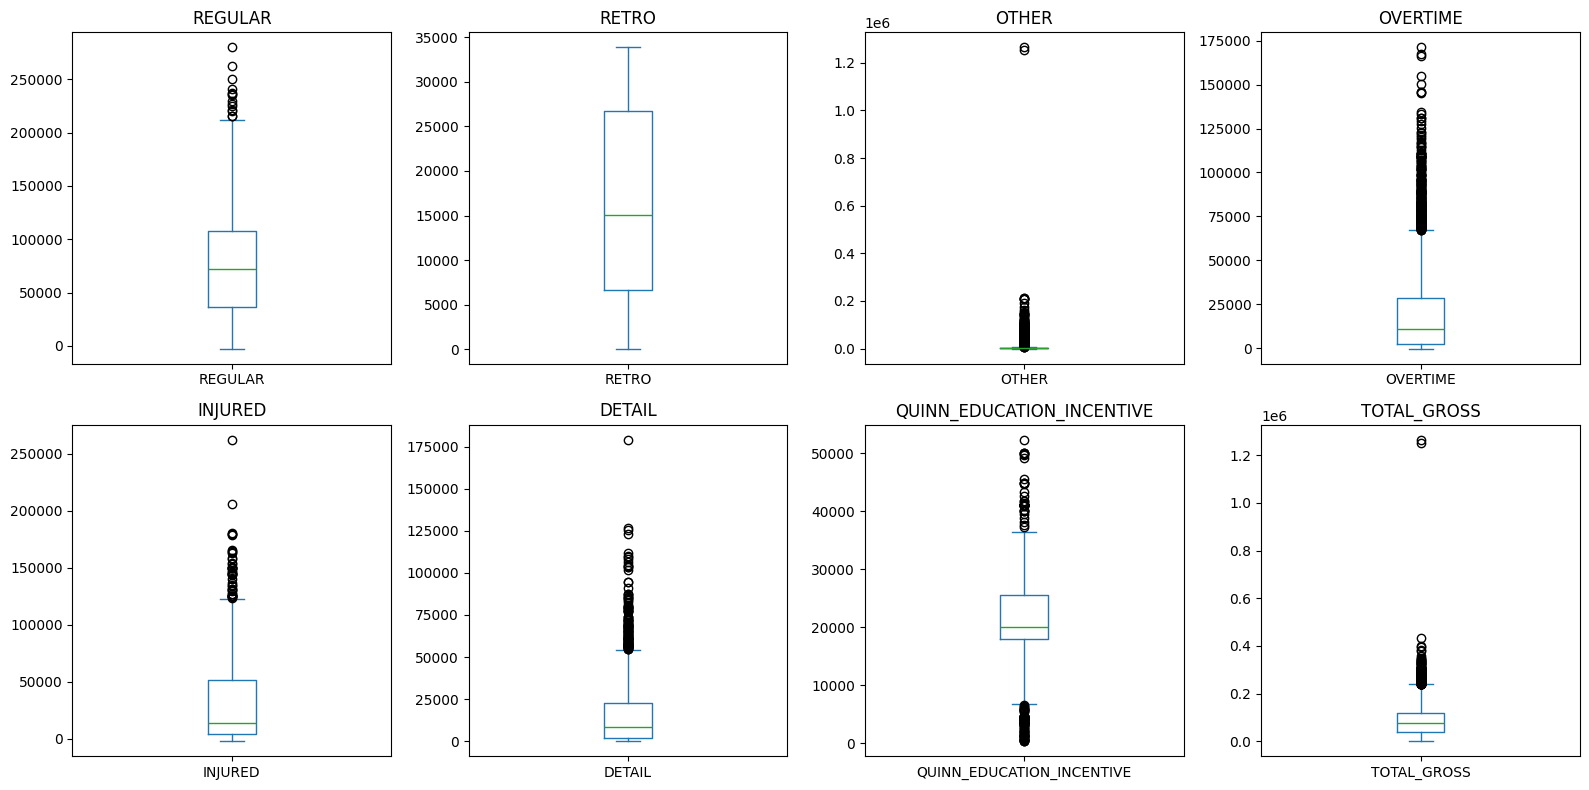

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean[col].dropna().plot(kind='box', ax=axes[i], title=col)

plt.tight_layout()
plt.show()

On these graph we clearly see that the column OTHER and TOTAL_GROSS have 2 outliers, they are clearly separated from the mass.

We also have one outlier in both column, INJURED and DETAIL, they seem apart from the mass.

## Remove the outliers

In [11]:
# Remove OTHER outliers
df_clean = df_clean[df_clean['TOTAL_GROSS'] < 1000000].copy()

We decided to only remove the 2 outliers found in TOTAL_GROSS and OTHER, we could dispute that they are linked but when we graph again the plots after removing them we clearly see that they were on the same row.

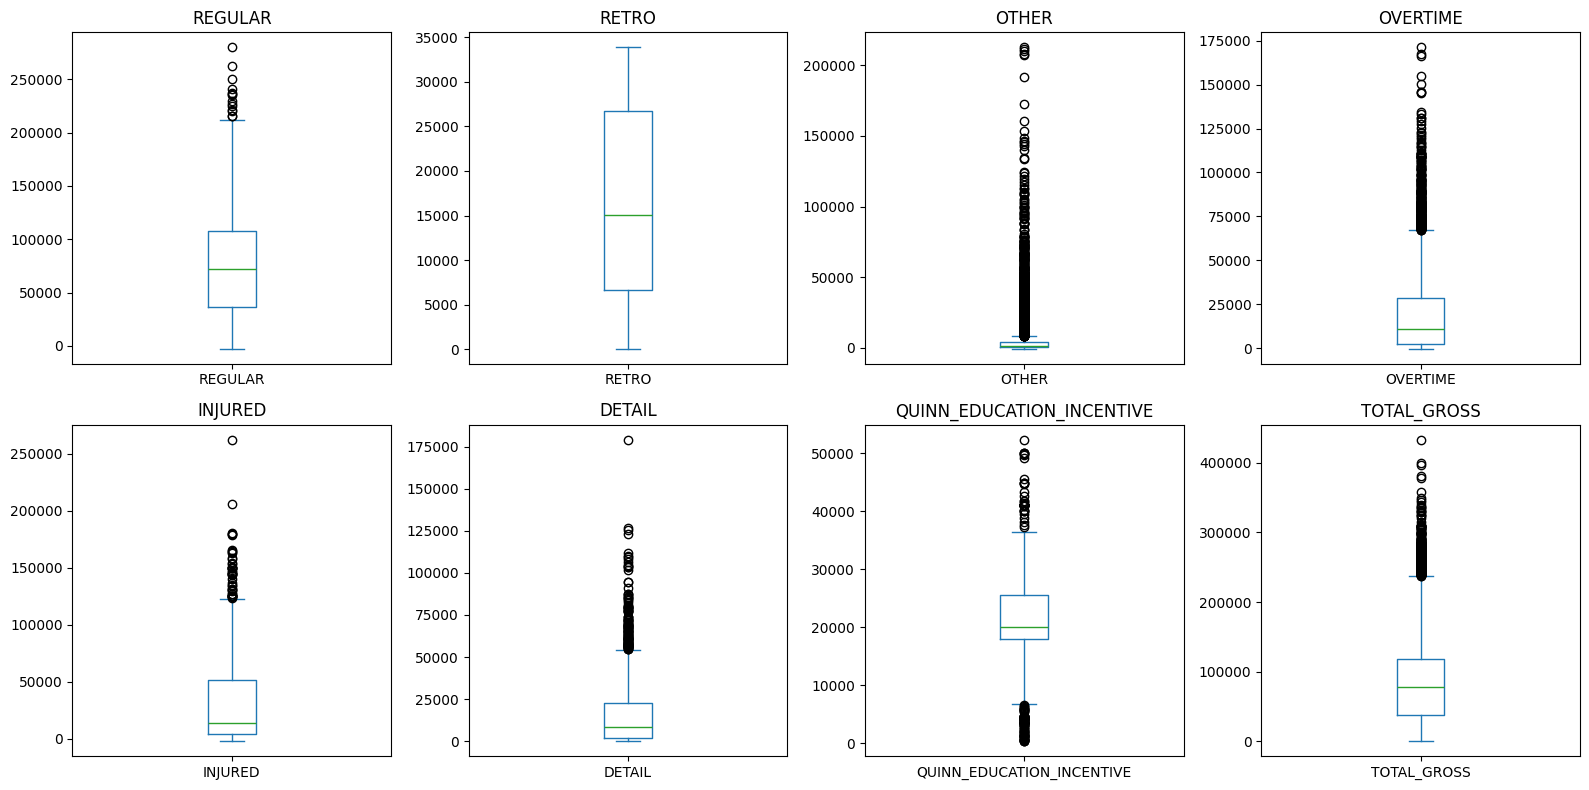

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean[col].dropna().plot(kind='box', ax=axes[i], title=col)

plt.tight_layout()
plt.show()

We can see now that the distributions are mainly all good. We could argue removing the top outliers in INJURED and DETAIL, but it is not clear enough if we remove them, because they aren't that far away.

# Prediction task

## Remove the useless columns 

In [13]:
df_clean.head()

,NAME,DEPARTMENT_NAME,TITLE,REGULAR,RETRO,OTHER,OVERTIME,INJURED,DETAIL,QUINN_EDUCATION_INCENTIVE,TOTAL_GROSS,POSTAL
2,"Harris,Shawn N",Boston Police Department,Police Offc Comm Serv Offc 3$8,69772.10,NaN,212739.48,82300.87,30939.24,12144.0,25178.06,433073.75,02130
3,"Washington,Walter",Boston Police Department,Police Officer,100963.38,NaN,211900.28,67849.66,NaN,9016.0,10096.55,399825.87,02368
4,"Mosley Jr.,Curtis",Boston Police Department,Police Offc Comm Serv Offc 3$8,109858.02,NaN,192097.54,75938.65,NaN,19550.0,NaN,397444.21,02301
5,"Joseph,Martin M",Boston Police Department,Police Sergeant (Det),127626.76,NaN,124524.50,66433.83,NaN,50085.0,12762.78,381432.87,02124
6,"Demesmin,Stanley",Boston Police Department,Police Lieutenant (Det),142466.41,NaN,15820.50,167509.61,NaN,24695.0,28198.49,378690.01,02052


In [18]:
from sklearn.model_selection import train_test_split

df_features = df_clean.drop(columns=['NAME', 'DEPARTMENT_NAME', 'TITLE', 'POSTAL'])
df_target = df_clean['DEPARTMENT_NAME']

x_train, x_test, y_train, y_test = train_test_split(
    df_features,
    df_target,
    test_size=0.1,
    random_state=42
)


We have to predict the department_name only using informations on the salary and bonuses, so we removed anything not related to this.

We did split the data to train it and then test it, to be able to measure metrics like F1-scores.

**Do some classifiers in scikit-learn accept missing values?**

While most classifier do not handle missing values, and will raise an error. HistGradientBoostingClassifier is the main scikit-learn classifier that accepts missing values


## Majority class

In [26]:
from sklearn.metrics import f1_score

majority_class = y_train.value_counts().idxmax()
print("Majority class:", majority_class)

y_pred = [majority_class] * len(y_test) 

score = f1_score(y_test, y_pred, average='micro')
print("F1 score (micro-average):", score)

Majority class: Boston Police Department
F1 score (micro-average): 0.13880266075388026


## Imputation / Classifiers combinations

Let's try all thoses different combinations of imputers and classifiers :

Imputers :
- Zero
- Median
- KNN
- Iterative

Classifiers : 
- KNN
- Decision tree
- Random Forest

In [38]:
# Step 0: imports

from sklearn.experimental import enable_iterative_imputer

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score


# Step 1: define classifiers
classifiers = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Step 2: define imputers (only the four you mentioned)
imputers = {
    "Zero Imputation": SimpleImputer(strategy="constant", fill_value=0),
    "Median Imputation": SimpleImputer(strategy="median"),
    "KNN Imputation": KNNImputer(n_neighbors=5),
    "Iterative Imputation": IterativeImputer(random_state=42)
}

# Step 3: loop through all combinations
f1_scores = {}

for imp_name, imputer in imputers.items():
    for clf_name, clf in classifiers.items():
        pipeline = Pipeline([
            ("imputer", imputer),
            ("classifier", clf)
        ])
        
        # Train
        pipeline.fit(x_train, y_train)
        
        # Predict
        y_pred = pipeline.predict(x_test)
        
        # Compute micro F1
        key = f"{clf_name} + {imp_name}"
        f1_scores[key] = f1_score(y_test, y_pred, average="micro")

# Step 4: print results sorted by F1
print("Micro F1 scores for all combinations:\n")
for key, score in sorted(f1_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{key}: {score:.4f}")

# Step 5: best combination
best_combo = max(f1_scores, key=f1_scores.get)
print(f"\nBest combination: {best_combo} with Micro F1 = {f1_scores[best_combo]:.4f}")

Micro F1 scores for all combinations:

Random Forest + Median Imputation: 0.2820
Random Forest + Zero Imputation: 0.2812
Random Forest + Iterative Imputation: 0.2683
Random Forest + KNN Imputation: 0.2661
Decision Tree + Median Imputation: 0.2621
Decision Tree + Zero Imputation: 0.2599
Decision Tree + Iterative Imputation: 0.2541
KNN + Iterative Imputation: 0.2377
KNN + Median Imputation: 0.2346
Decision Tree + KNN Imputation: 0.2346
KNN + Zero Imputation: 0.2324
KNN + KNN Imputation: 0.2279

Best combination: Random Forest + Median Imputation with Micro F1 = 0.2820
